## About the Project

This project uses Python to simulate a simplified SSD and explore how write amplification and channel parallelism affect B-tree performance. The simulation includes a simple flash device and a flash translation layer (FTL) that model the basic behavior of a real SSD, such as out of place writes and garbage collection.

The project compares two tree designs: a traditional in place B-tree and a write optimized tree that batches updates before writing them to the SSD. Both trees are tested with different workloads to measure write amplification and to see how it changes as the SSD becomes fuller.

The project also includes a second simulation that models an SSD with multiple channels. It compares serial and batched execution of flash operations to show how using multiple channels can improve performance.



#### Step 1

This code builds a simplified SSD model to measure write amplification. The `FlashDevice` class models the flash memory as blocks of pages and follows the basic rule that a page cannot be overwritten until its entire block is erased. The `FTL` class acts as the SSD firmware. It keeps track of where data is stored, writes updates to new pages instead of overwriting old ones, and runs garbage collection when free space becomes limited.

The simulation compares two tree designs: `InPlaceBTree`, which writes every update immediately, and `WriteOptimizedTree`, which buffers updates and writes them in batches. The `workload` function generates four access patterns—sequential, random, update heavy, and read heavy—and `run_one` executes a selected tree on one of these workloads while recording both logical and physical writes.

In [2]:
# Experiment 1 (v2): Write Amplification Simulation
# Higher device utilization + decomposed metrics

import random
import matplotlib.pyplot as plt
random.seed(42)


# 1. Simulated flash device
class FlashDevice:
    def __init__(self, num_blocks=32, pages_per_block=16):
        self.num_blocks = num_blocks
        self.pages_per_block = pages_per_block
        self.total_pages = num_blocks * pages_per_block
        self.page_state = ['free'] * self.total_pages
        self.physical_writes = 0
        self.block_erases = 0

    def block_of(self, p):
        return p // self.pages_per_block

    def pages_in_block(self, b):
        s = b * self.pages_per_block
        return range(s, s + self.pages_per_block)

    def program_page(self, p):
        assert self.page_state[p] == 'free', "page not free"
        self.page_state[p] = 'valid'
        self.physical_writes += 1

    def invalidate_page(self, p):
        if self.page_state[p] == 'valid':
            self.page_state[p] = 'invalid'

    def erase_block(self, b):
        for p in self.pages_in_block(b):
            self.page_state[p] = 'free'
        self.block_erases += 1

    def free_page_count(self):
        return self.page_state.count('free')

    def find_free_page(self):
        for p in range(self.total_pages):
            if self.page_state[p] == 'free':
                return p
        return None


# 2. Flash Translation Layer
class FTL:
    def __init__(self, device, gc_threshold=0.10):
        self.dev = device
        self.map = {}
        self.gc_threshold = gc_threshold

    def _ensure_space(self):
        min_free = int(self.dev.total_pages * self.gc_threshold)
        while self.dev.free_page_count() <= min_free:
            before = self.dev.free_page_count()
            reclaimed = self._garbage_collect()
            if not reclaimed:
                break
            if self.dev.free_page_count() <= before:
                break  # no progress; avoid infinite loop

    def _garbage_collect(self):
        best_block, best_valid = None, None
        for b in range(self.dev.num_blocks):
            states = [self.dev.page_state[p] for p in self.dev.pages_in_block(b)]
            if all(s == 'free' for s in states):
                continue
            valid = states.count('valid')
            if best_valid is None or valid < best_valid:
                best_block, best_valid = b, valid
        if best_block is None:
            return False

        to_move = [lp for lp, pp in self.map.items()
                   if self.dev.block_of(pp) == best_block
                   and self.dev.page_state[pp] == 'valid']

        self.dev.erase_block(best_block)

        for lp in to_move:
            newp = self.dev.find_free_page()
            if newp is None:
                break
            self.dev.program_page(newp)
            self.map[lp] = newp
        return True

    def write_logical(self, lp):
        self._ensure_space()
        if lp in self.map:
            self.dev.invalidate_page(self.map[lp])
        newp = self.dev.find_free_page()
        self.dev.program_page(newp)
        self.map[lp] = newp


# 3. The two tree designs
class InPlaceBTree:
    def __init__(self, ftl, keys_per_node=32):
        self.ftl = ftl
        self.keys_per_node = keys_per_node
        self.logical_writes = 0

    def _page(self, key):
        return key // self.keys_per_node

    def write(self, key):
        self.ftl.write_logical(self._page(key))
        self.logical_writes += 1


class WriteOptimizedTree:
    def __init__(self, ftl, keys_per_node=32, batch_size=64):
        self.ftl = ftl
        self.keys_per_node = keys_per_node
        self.batch_size = batch_size
        self.buffer = []
        self.logical_writes = 0

    def _page(self, key):
        return key // self.keys_per_node

    def write(self, key):
        self.buffer.append(key)
        if len(self.buffer) >= self.batch_size:
            self.flush()

    def flush(self):
        if not self.buffer:
            return
        for lp in set(self._page(k) for k in self.buffer):
            self.ftl.write_logical(lp)
            self.logical_writes += 1
        self.buffer.clear()


# 4. Workloads (working set W controls device utilization)
def workload(kind, n_ops=20000, W=12000):
    if kind == 'sequential':
        return [i % W for i in range(n_ops)]
    if kind == 'random':
        return [random.randint(0, W - 1) for _ in range(n_ops)]
    if kind == 'update_heavy':
        hot = list(range(W // 4))          # concentrated writes
        return [random.choice(hot) for _ in range(n_ops)]
    if kind == 'read_heavy':
        return [random.randint(0, W - 1)
                for _ in range(n_ops) if random.random() < 0.10]
    raise ValueError(kind)


# 5. Runner with decomposed metrics
def run_one(tree_kind, wl_kind):
    dev = FlashDevice(num_blocks=32, pages_per_block=16)   # 512 pages
    ftl = FTL(dev, gc_threshold=0.10)
    tree = InPlaceBTree(ftl) if tree_kind == 'in_place' else WriteOptimizedTree(ftl)

    ops = workload(wl_kind)
    for key in ops:
        tree.write(key)
    if isinstance(tree, WriteOptimizedTree):
        tree.flush()

    requested = len(ops)                 # key-write operations asked for
    logical = tree.logical_writes        # page writes issued to FTL
    physical = dev.physical_writes       # page writes to flash
    tree_ratio = logical / requested if requested else float('nan')
    ftl_waf = physical / logical if logical else float('nan')
    total = physical / requested if requested else float('nan')
    return requested, logical, physical, dev.block_erases, tree_ratio, ftl_waf, total


def main():
    workloads = ['sequential', 'random', 'update_heavy', 'read_heavy']
    trees = ['in_place', 'write_optimized']
    hdr = f"{'Workload':<14}{'Tree':<17}{'Req':>7}{'Logical':>9}{'Phys':>8}{'TreeR':>8}{'FTL_WAF':>9}{'Total':>8}"
    print(hdr)
    print("-" * len(hdr))
    for wl in workloads:
        for t in trees:
            req, logi, phys, er, tr, waf, tot = run_one(t, wl)
            print(f"{wl:<14}{t:<17}{req:>7}{logi:>9}{phys:>8}{tr:>8.3f}{waf:>9.2f}{tot:>8.3f}")
        print()

main()

Workload      Tree                 Req  Logical    Phys   TreeR  FTL_WAF   Total
--------------------------------------------------------------------------------
sequential    in_place           20000    20000   55594   1.000     2.78   2.780
sequential    write_optimized    20000      625     625   0.031     1.00   0.031

random        in_place           20000    20000   50417   1.000     2.52   2.521
random        write_optimized    20000    18362   43135   0.918     2.35   2.157

update_heavy  in_place           20000    20000   20000   1.000     1.00   1.000
update_heavy  write_optimized    20000    14603   14603   0.730     1.00   0.730

read_heavy    in_place            2067     2067    3922   1.000     1.90   1.897
read_heavy    write_optimized     1980     1834    3224   0.926     1.76   1.628



***

#### Step 2

This block of code examines how write amplification changes as an SSD becomes fuller. The `run_utilization` function creates a new simulated SSD and selects a working set of keys so that the live data fills a chosen fraction of the device such as 30% or 90%. It then performs 20,000 random writes using the in place tree. After the writes are complete, it comes and calculates the write amplification factor by dividing the number of physical writes by the number of logical writes requested by the tree.

The code repeats this process for utilization levels ranging from 30% to 96%. For each level. And it prints the write amplification factor and plots the results on a line chart. Device utilization is shown on the x-axis and write amplification is shown on the y-axis.

utilization ~ 30%   FTL_WAF = 1.03
utilization ~ 45%   FTL_WAF = 1.21
utilization ~ 60%   FTL_WAF = 1.60
utilization ~ 70%   FTL_WAF = 2.20
utilization ~ 80%   FTL_WAF = 3.74
utilization ~ 88%   FTL_WAF = 13.67
utilization ~ 93%   FTL_WAF = 27.93
utilization ~ 96%   FTL_WAF = 27.82


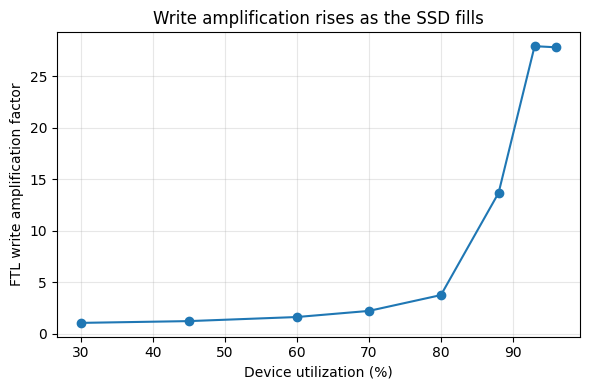

In [3]:
# Experiment 1b: Write amplification vs device utilization
# This shows us FTL_WAF climbing as the drive fills up.

def run_utilization(util_fraction, n_ops=20000):
    """
    util_fraction sets how full the device's live data is.
    Smaller working set = emptier device = less amplification.
    Uses random writes + in-place tree (the clearest case).
    """
    dev = FlashDevice(num_blocks=32, pages_per_block=16)  # 512 pages
    ftl = FTL(dev, gc_threshold=0.10)
    tree = InPlaceBTree(ftl, keys_per_node=32)

    # working set sized to target utilization of the 512-page device
    live_pages = int(dev.total_pages * util_fraction)
    W = max(1, live_pages * tree.keys_per_node)

    for _ in range(n_ops):
        tree.write(random.randint(0, W - 1))

    return dev.physical_writes / tree.logical_writes

fractions = [0.30, 0.45, 0.60, 0.70, 0.80, 0.88, 0.93, 0.96]
wafs = [run_utilization(f) for f in fractions]

for f, w in zip(fractions, wafs):
    print(f"utilization ~{int(f*100):>3}%   FTL_WAF = {w:.2f}")

plt.figure(figsize=(6, 4))
plt.plot([f*100 for f in fractions], wafs, marker='o')
plt.xlabel("Device utilization (%)")
plt.ylabel("FTL write amplification factor")
plt.title("Write amplification rises as the SSD fills")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("waf_vs_utilization.png", dpi=150)
plt.show()

***

#### Step 3

This code block here, models how multiple SSD channels affect performance. The ParallelFlashModel class represents an SSD with a configurable number of channels and assigns a realistic execution time to each flash operation. It can executes the same workload in two ways. In the serial version, we know taht the operations run one after another on a single channel. But in the batched version, they are distributed across all available channels and run in parallel.

The experiment has two parts. The first part comes and compares serial and batched execution for three different workloads on an 8-channel SSD. The second part, keep the workload fixed and varies the number of channels from 1 to 32. It then compares the measured speedup with the ideal linear speedup.

Channels = 8
Scenario                      Serial(ms)  Batched(ms)  Speedup
--------------------------------------------------------------
read-mostly lookup batch           61.68         7.71     8.00
mixed insert batch                281.64        36.71     7.67
write-heavy batch                 556.90        71.84     7.75

channels =  1   speedup = 1.00x
channels =  2   speedup = 2.00x
channels =  4   speedup = 4.00x
channels =  8   speedup = 7.67x
channels = 16   speedup = 14.19x
channels = 32   speedup = 27.74x


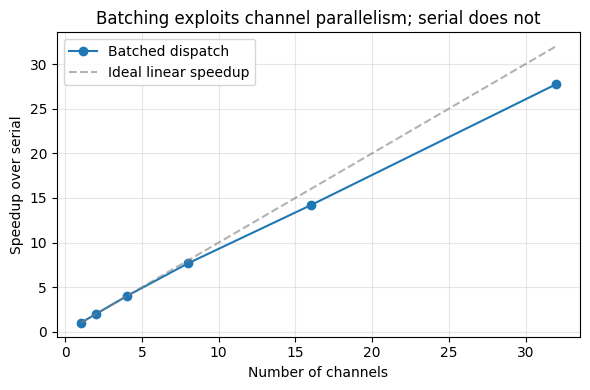

In [4]:
# Experiment 2: Block-Level Parallelism
# Serial vs. batched dispatch across C flash channels.
# Self-contained
# NAND flash operation latencies (microseconds).
# Representative values from published NAND datasheets / studies.
# Reads are fast; programs (writes) slower; erases slowest.

LAT = {
    'read':    50,     # ~50 us page read
    'program': 500,    # ~500 us page program (write)
    'erase':   3000,   # ~3 ms block erase
}
DISPATCH_OVERHEAD = 2

class ParallelFlashModel:
    """
    C channels, each serving one op at a time.
    Serial: ops run end-to-end on effectively one channel (dependency-bound).
    Batched: ops distributed round-robin across channels; total time is
             set by the busiest channel.
    """
    def __init__(self, channels=8):
        self.channels = channels

    def _op_time(self, op):
        return LAT[op] + DISPATCH_OVERHEAD

    def serial_time(self, ops):
        # every op waits for the previous one: pure sum
        return sum(self._op_time(op) for op in ops)

    def batched_time(self, ops):
        # distribute ops round-robin; each channel sums its own load;
        # wall-clock = the busiest channel
        loads = [0.0] * self.channels
        for i, op in enumerate(ops):
            loads[i % self.channels] += self._op_time(op)
        return max(loads)


def make_ops(n_reads, n_writes, n_erases):
    return (['read'] * n_reads) + (['program'] * n_writes) + (['erase'] * n_erases)


# Part 1: Serial vs batched on a few representative workloads
def part1():
    C = 8
    model = ParallelFlashModel(channels=C)

    scenarios = {
        'read-mostly lookup batch':  make_ops(800, 40, 0),
        'mixed insert batch':        make_ops(400, 400, 20),
        'write-heavy batch':         make_ops(100, 800, 50),
    }

    print(f"Channels = {C}")
    print(f"{'Scenario':<28}{'Serial(ms)':>12}{'Batched(ms)':>13}{'Speedup':>9}")
    print("-" * 62)
    for name, ops in scenarios.items():
        s = model.serial_time(ops) / 1000.0     # us -> ms
        b = model.batched_time(ops) / 1000.0
        print(f"{name:<28}{s:>12.2f}{b:>13.2f}{s/b:>9.2f}")
    print()


# Part 2: Speedup vs channel count (the figure)
def part2():
    ops = make_ops(400, 400, 20)          # fixed mixed batch
    serial = ParallelFlashModel(1).serial_time(ops)

    channel_counts = [1, 2, 4, 8, 16, 32]
    speedups = []
    for c in channel_counts:
        t = ParallelFlashModel(c).batched_time(ops)
        speedups.append(serial / t)

    for c, sp in zip(channel_counts, speedups):
        print(f"channels = {c:>2}   speedup = {sp:.2f}x")

    plt.figure(figsize=(6, 4))
    plt.plot(channel_counts, speedups, marker='o', label='Batched dispatch')
    plt.plot(channel_counts, channel_counts, linestyle='--',
             color='gray', alpha=0.6, label='Ideal linear speedup')
    plt.xlabel("Number of channels")
    plt.ylabel("Speedup over serial")
    plt.title("Batching exploits channel parallelism; serial does not")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("speedup_vs_channels.png", dpi=150)
    plt.show()


part1()
part2()

***

💫